# Exercise

>Source of the exercise:<br>
>Chapter 4.4 of **Marco Peixeiro**'s book **Time Series Forecasting in Python** 
>
>The solutions provided by the author can be found [here](https://github.com/marcopeix/TimeSeriesForecastingInPython/blob/master/CH04/CH04_exercises_solution.ipynb).

## 1. Simulate an MA(2) process and make forecasts

Simulate a stationary MA(2) process. To do so, use the `ArmaProcess`
function from the statsmodels library and simulate the following
process:<br>
$y_t = 0.9θ_{t–1} + 0.3θ_{t–2}$

1. For this exercise, generate 1,000 samples.<br>
    ```python
    from statsmodels.tsa.arima_process import ArmaProcess
    import numpy as np
    np.random.seed(42) # Set the seed for reproducibility. Change the seed if you want to experiment with different values.
    ma2 = np.array([1, 0.9, 0.3])
    ar2 = np.array([1, 0, 0])
    MA2_process = ArmaProcess(ar2, ma2).generate_sample(nsample=1000)
    ```
    


2. Plot your simulated moving average.
3. Run the ADF test, and check if the process is stationary.
4. Plot the ACF, and see if there are significant coefficients after lag 2.
5. Separate your simulated series into train and test sets. Take the first 800 timesteps for the train set, and assign the rest to the test set.
6. Make forecasts over the test set. Use the mean, last value, and an MA(2) model. Make sure you repeatedly forecast 2 timesteps at a time using the `recursive_forecast` function we defined.
7. Plot your forecasts.
8. Measure the MSE, and identify your champion model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima_process import ArmaProcess

In [2]:
# 1. Generate 1,000 samples.

np.random.seed(42)  # Set the seed for reproducibility. Change the seed if you want to experiment with different values.
ma2 = np.array([1, 0.9, 0.3])
ar2 = np.array([1, 0, 0])
MA2_process = ArmaProcess(ar2, ma2).generate_sample(nsample=1000)

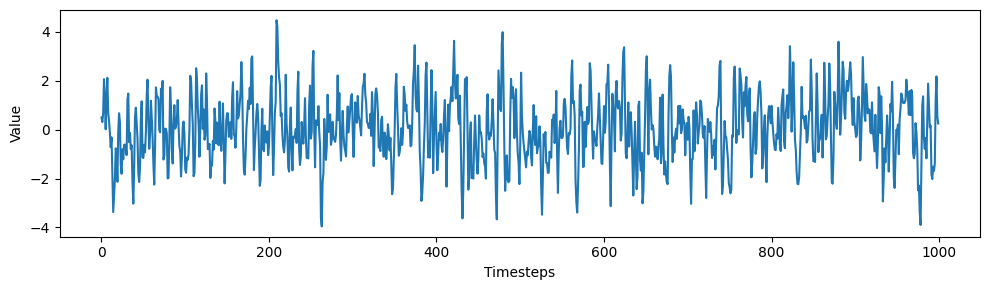

In [3]:
# 2. Plot your simulated moving average.

plt.figure(figsize=(10, 3))
plt.plot(MA2_process)
plt.xlabel("Timesteps")
plt.ylabel("Value")

plt.tight_layout()

In [4]:
# 3. Run the ADF test, and check if the process is stationary.

from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(MA2_process)

print(f"ADF Statistic: {ADF_result[0]}")
print(f"p-value: {ADF_result[1]}")

ADF Statistic: -14.005444309194491
p-value: 3.795601616713556e-26


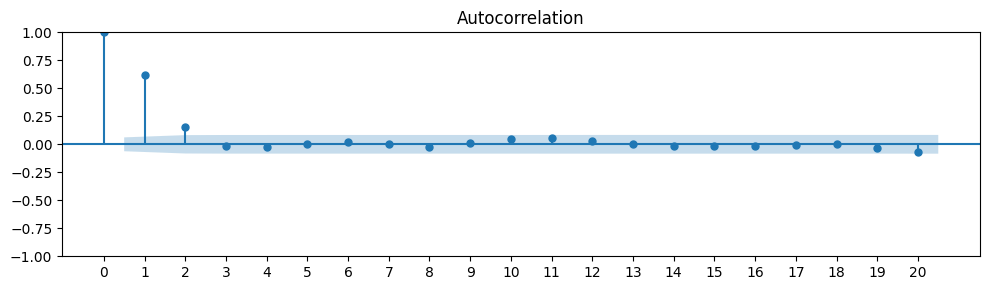

In [5]:
# 4. Plot the ACF, and see if there are significant coefficients after lag 2.

from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 3))

plot_acf(MA2_process, lags=20, ax=ax)
ax.set_xticks(range(0, 21))
plt.tight_layout()
plt.show()

In [6]:
# 5. Separate your simulated series into train and test sets.

df = pd.DataFrame({"value": MA2_process})

train = df[:800]
test = df[800:]

In [7]:
# 6. Make forecasts over the test set. Use the mean, last value, and an MA(2) model.
# Make sure you repeatedly forecast 2 timesteps at a time using the `recursive_forecast` function we defined.

The `rolling_forcast` function was defined in the book. Pasting it here:

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    """
    Generate rolling forecasts for a time series using different forecasting methods.

    The function takes a DataFrame containing the full time series, separates the
    initial observations into a training set, and then generates forecasts for
    the remaining observations. Forecasts are generated in batches determined by
    the `window` parameter.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the complete time series. The DataFrame is expected
        to contain a single column representing the moving average
        process.

    train_len : int
        Number of observations used as the initial training set.

        For example, if `train_len = 800`, the first 800 observations are used
        to estimate the forecasting model, and forecasting begins from
        observation 801 onward.

    horizon : int
        Number of observations to forecast beyond the training set.

        For example, if `horizon = 200` and `train_len = 800`, forecasts are
        generated for the next 200 observations, giving a total forecasting
        period from observation 801 to observation 1000.

    window : int
        Number of time steps forecast at each iteration.

        For example, if `window = 2`, forecasts are generated two steps at a
        time. After each forecasting step, the available historical data is
        updated and the model can be re-estimated.

    method : str
        Forecasting method to use. The function supports the following methods:

        - `"mean"`:
            Forecast the mean of all observations available up to the current
            forecasting point.

        - `"last"`:
            Forecast using the most recently observed value. This is also known
            as the naive or last-value forecasting method.

        - `"MA"`:
            Fit an MA(2) model using the observations available up to the current
            forecasting point and generate forecasts for the next `window`
            observations. The MA(2) model is implemented using the SARIMAX model
            with `order=(0, 0, 2)`.

    Returns
    -------
    list
        A list containing the out-of-sample forecasts for the entire forecasting
        horizon.

        The length of the returned list is expected to be equal to `horizon`.

    Notes
    -----
    The variable `total_len` represents the total number of observations used
    after combining the training set and forecasting horizon:

        total_len = train_len + horizon

    During each iteration, the observations from the beginning of the series
    up to the current forecasting point are used as the available history.

    For the `"MA"` method, the model is re-estimated at each iteration using
    all observations available up to that point. This produces a rolling
    forecasting procedure in which new observations can be incorporated as the
    forecasting process progresses.

    The MA(q) model is a special case of the more general ARIMA/SARIMAX
    framework. In this implementation, `order=(0, 0, 2)` specifies an MA(2)
    model:

        AR order = 0
        Differencing order = 0
        MA order = 2

    The `predicted_mean` returned by `get_prediction()` contains the predicted
    values generated by the fitted statsmodels model.
    """

    total_len = train_len + horizon

    if method == "mean":
        pred_mean = []

        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))

        return pred_mean

    elif method == "last":
        pred_last_value = []

        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))

        return pred_last_value

    elif method == "MA":
        pred_MA = []

        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0, 0, 2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_MA.extend(oos_pred)

        return pred_MA

In [9]:
train_len = len(train)
test_len = len(test)
window = 2

pred_mean = rolling_forecast(df, train_len=train_len, horizon=test_len, window=window, method="mean")
pred_last_value = rolling_forecast(df, train_len=train_len, horizon=test_len, window=window, method="last")
pred_MA2 = rolling_forecast(df, train_len=train_len, horizon=test_len, window=window, method="MA")

test.loc[:, "pred_mean"] = pred_mean
test.loc[:, "pred_last_value"] = pred_last_value
test.loc[:, "pred_MA2"] = pred_MA2

test.head()

,value,pred_mean,pred_last_value,pred_MA2
800,0.973560,-0.017430,0.259693,0.065366
801,0.337338,-0.017430,0.259693,0.017984
802,-0.086834,-0.015752,0.337338,-0.180397
803,-0.530580,-0.015752,0.337338,-0.116820
804,-0.821708,-0.016481,-0.530580,-0.405768


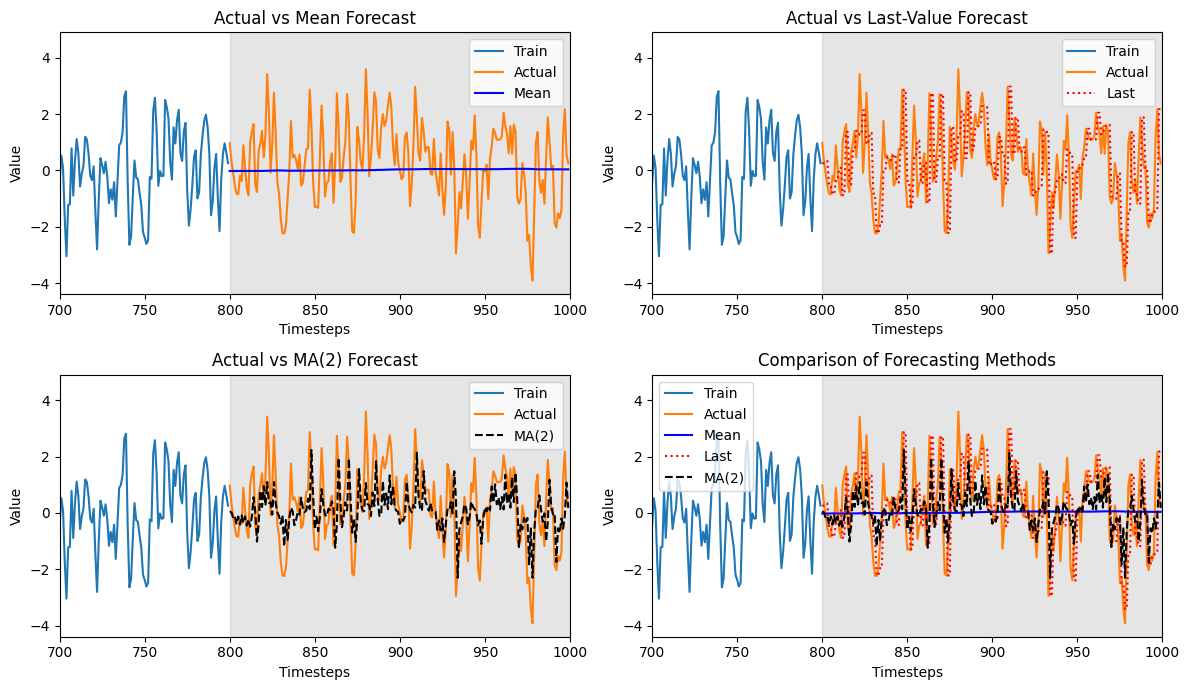

In [10]:
# 7. Plot your forecasts.

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Mean forecasting method
ax = axes[0, 0]

ax.plot(train, label="Train")
ax.plot(test["value"], label="Actual")
ax.plot(test["pred_mean"], "b-", label="Mean")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.set_title("Actual vs Mean Forecast")
ax.legend(loc="best")

ax.axvspan(800, 1000, color="#808080", alpha=0.2)
ax.set_xlim(700, 1000)


# Last-value forecasting method
ax = axes[0, 1]

ax.plot(train, label="Train")
ax.plot(test["value"], label="Actual")
ax.plot(test["pred_last_value"], "r:", label="Last")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.set_title("Actual vs Last-Value Forecast")
ax.legend(loc="best")

ax.axvspan(800, 1000, color="#808080", alpha=0.2)
ax.set_xlim(700, 1000)


# MA(2) forecasting method
ax = axes[1, 0]

ax.plot(train, label="Train")
ax.plot(test["value"], label="Actual")
ax.plot(test["pred_MA2"], "k--", label="MA(2)")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.set_title("Actual vs MA(2) Forecast")
ax.legend(loc="best")

ax.axvspan(800, 1000, color="#808080", alpha=0.2)
ax.set_xlim(700, 1000)


# Comparison of all forecasting methods
ax = axes[1, 1]

ax.plot(train, label="Train")
ax.plot(test["value"], label="Actual")
ax.plot(test["pred_mean"], "b-", label="Mean")
ax.plot(test["pred_last_value"], "r:", label="Last")
ax.plot(test["pred_MA2"], "k--", label="MA(2)")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.set_title("Comparison of Forecasting Methods")
ax.legend(loc="best")

ax.axvspan(800, 1000, color="#808080", alpha=0.2)
ax.set_xlim(700, 1000)


plt.tight_layout()
plt.show()

In [11]:
# 8. Measure the MSEs, and identify your champion model.

from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test["value"], test["pred_mean"])
mse_last = mean_squared_error(test["value"], test["pred_last_value"])
mse_MA = mean_squared_error(test["value"], test["pred_MA2"])

print(round(mse_mean, 4), round(mse_last, 4), round(mse_MA, 4))

1.8635 1.9882 1.2324


The lowest MSE is from MA(2) model.

## 2 Simulate an MA(q) process and make forecasts 

Recreate the previous exercise, but simulate a moving average process of your choice. Try simulating a third-order or fourth-order moving average process. I recommend generating 10,000 samples. <br>
Be especially attentive to the ACF, and see if your coefficients become non-significant after lag q.

In [12]:
# 1. Generate 5,000 samples.
# Note: I had tried to run for 10,000 as mentioned in the exercise.
#       But had to reduce it to 5,000 as 10,000 samples were leading
#       to huge time consumption while modelling.

np.random.seed(42)  # Set the seed for reproducibility. Change the seed if you want to experiment with different values.
ma4 = np.array([1, 0.8, 0.3, -0.75, -0.35])  # MA(4)
ar2 = np.array([1, 0, 0])
MA4_process = ArmaProcess(ar2, ma4).generate_sample(nsample=5000)

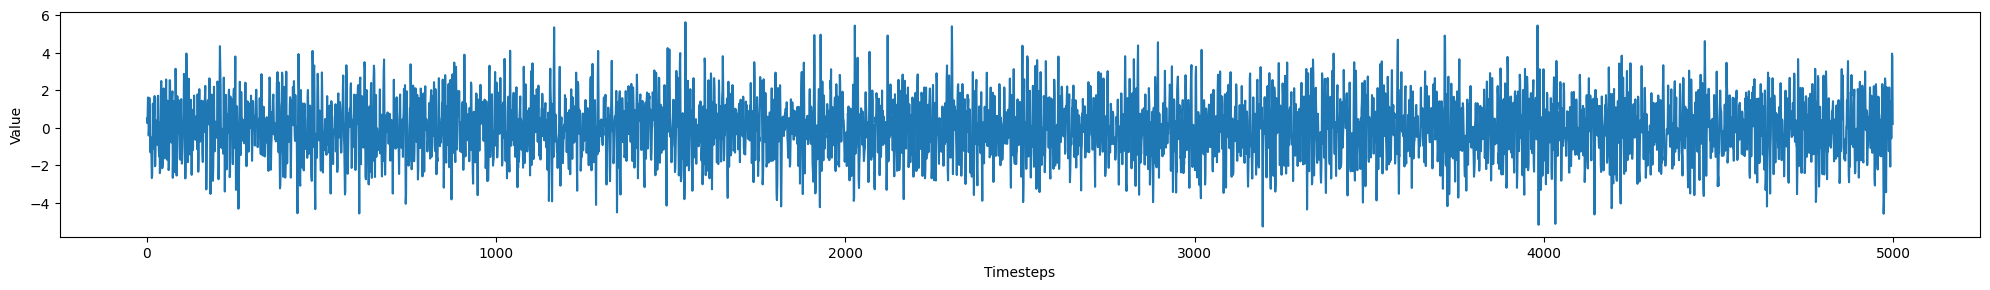

In [13]:
# 2. Plot your simulated moving average.

plt.figure(figsize=(20, 3))
plt.plot(MA4_process)
plt.xlabel("Timesteps")
plt.ylabel("Value")

plt.tight_layout()

In [14]:
# 3. Run the ADF test, and check if the process is stationary.

from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(MA4_process)

print(f"ADF Statistic: {ADF_result[0]}")
print(f"p-value: {ADF_result[1]}")

ADF Statistic: -12.166607241038465
p-value: 1.4524465859571024e-22


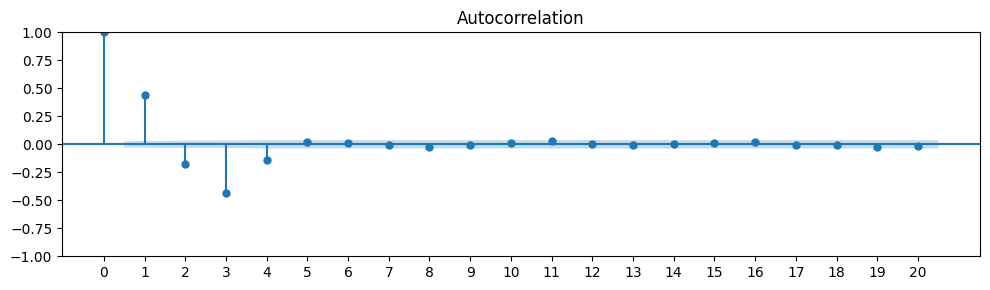

In [15]:
# 4. Plot the ACF, and see if there are significant coefficients after lag 4.

from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 3))

plot_acf(MA4_process, lags=20, ax=ax)
ax.set_xticks(range(0, 21))
plt.tight_layout()
plt.show()

In [16]:
# 5. Separate your simulated series into train and test sets.

df2 = pd.DataFrame({"value": MA4_process})

train = df2[:4000]
test = df2[4000:]

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


def rolling_forecast4(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    """
    This is the same function as defined before, only change is at this line:

    model = SARIMAX(df[:i], order=(0, 0, 4))

    Earlier the order was (0, 0, 2) for MA(2) method.
    Now, it has been changed accordingly for MA(4).

    """

    total_len = train_len + horizon

    if method == "mean":
        pred_mean = []

        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))

        return pred_mean

    elif method == "last":
        pred_last_value = []

        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))

        return pred_last_value

    elif method == "MA":
        pred_MA = []

        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0, 0, 4))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_MA.extend(oos_pred)

        return pred_MA

In [18]:
# 6. Make forecasts over the test set. Use the mean, last value, and an MA(4) model.
# Make sure you repeatedly forecast 4 timesteps at a time using the `recursive_forecast` function we defined.

train_len = len(train)
test_len = len(test)
window = 4

pred_mean = rolling_forecast4(df2, train_len=train_len, horizon=test_len, window=window, method="mean")
pred_last_value = rolling_forecast4(df2, train_len=train_len, horizon=test_len, window=window, method="last")
pred_MA4 = rolling_forecast4(df2, train_len=train_len, horizon=test_len, window=window, method="MA")

test.loc[:, "pred_mean"] = pred_mean
test.loc[:, "pred_last_value"] = pred_last_value
test.loc[:, "pred_MA4"] = pred_MA4

In [19]:
test.head()

,value,pred_mean,pred_last_value,pred_MA4
4000,0.885496,0.01938,3.127660,1.649157
4001,-1.734233,0.01938,3.127660,-1.014817
4002,-1.111662,0.01938,3.127660,-0.791153
4003,0.999076,0.01938,3.127660,-0.109340
4004,-0.657724,0.01912,0.999076,0.815831


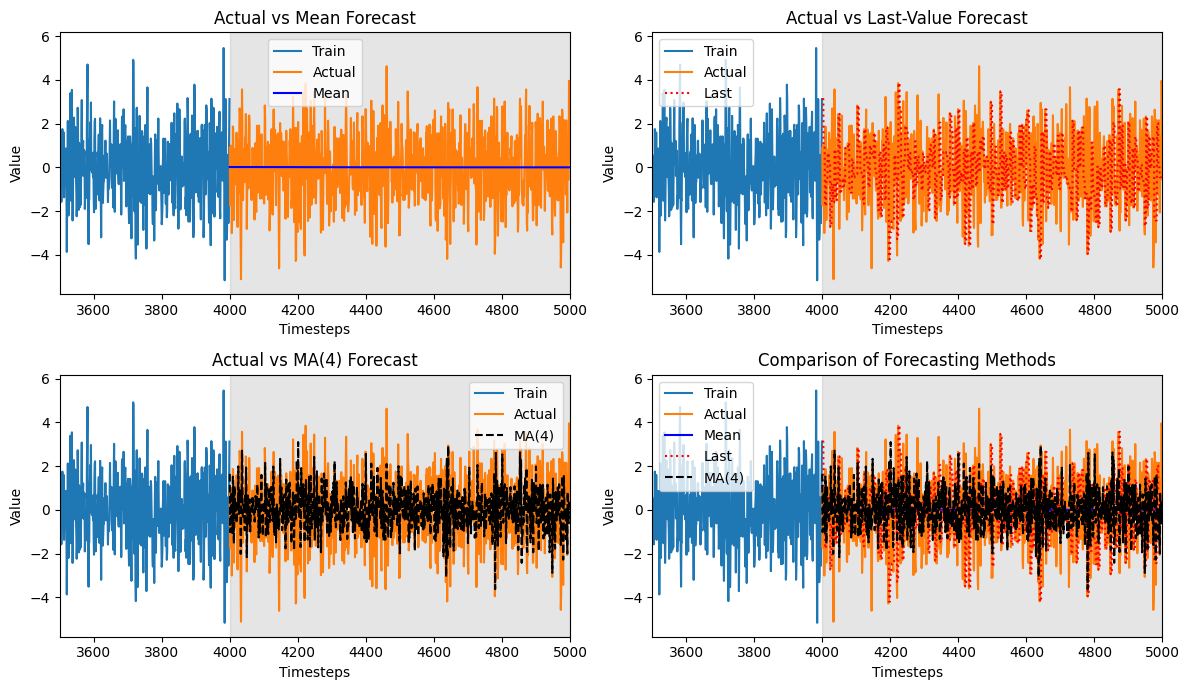

In [20]:
# 7. Plot your forecasts.

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Mean forecasting method
ax = axes[0, 0]

ax.plot(train, label="Train")
ax.plot(test["value"], label="Actual")
ax.plot(test["pred_mean"], "b-", label="Mean")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.set_title("Actual vs Mean Forecast")
ax.legend(loc="best")

ax.axvspan(4000, 5000, color="#808080", alpha=0.2)
ax.set_xlim(3500, 5000)


# Last-value forecasting method
ax = axes[0, 1]

ax.plot(train, label="Train")
ax.plot(test["value"], label="Actual")
ax.plot(test["pred_last_value"], "r:", label="Last")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.set_title("Actual vs Last-Value Forecast")
ax.legend(loc="best")

ax.axvspan(4000, 5000, color="#808080", alpha=0.2)
ax.set_xlim(3500, 5000)


# MA(4) forecasting method
ax = axes[1, 0]

ax.plot(train, label="Train")
ax.plot(test["value"], label="Actual")
ax.plot(test["pred_MA4"], "k--", label="MA(4)")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.set_title("Actual vs MA(4) Forecast")
ax.legend(loc="best")

ax.axvspan(4000, 5000, color="#808080", alpha=0.2)
ax.set_xlim(3500, 5000)


# Comparison of all forecasting methods
ax = axes[1, 1]

ax.plot(train, label="Train")
ax.plot(test["value"], label="Actual")
ax.plot(test["pred_mean"], "b-", label="Mean")
ax.plot(test["pred_last_value"], "r:", label="Last")
ax.plot(test["pred_MA4"], "k--", label="MA(4)")

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
ax.set_title("Comparison of Forecasting Methods")
ax.legend(loc="best")

ax.axvspan(4000, 5000, color="#808080", alpha=0.2)
ax.set_xlim(3500, 5000)


plt.tight_layout()
plt.show()

In [21]:
# 8. Measure the MSEs, and identify your champion model.

from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test["value"], test["pred_mean"])
mse_last = mean_squared_error(test["value"], test["pred_last_value"])
mse_MA = mean_squared_error(test["value"], test["pred_MA4"])

print(round(mse_mean, 4), round(mse_last, 4), round(mse_MA, 4))

2.3615 4.8374 1.6631


The lowest MSE is from MA(4) model.